# Notebook 04 — LSAPI

Implements the Least Squares Approximate Policy Iteration (LSAPI) algorithm from §3.3–3.4 and §4 of Löhndorf & Minner (2009).

**Goals:**
- Run LSAPI-2 and LSAPI-3 with the default parameter configuration.
- Plot the convergence of the weight vector and value function approximation.
- Visualise the learned policies as contour plots (replicating Figs. 2b, 2c, 3b, 3c).
- Compare mean rewards: LP vs LSAPI-2 vs LSAPI-3 (replicating Table 2).

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from stochastic import StochasticParams
from environment import EnvParams
from basis_functions import PolynomialApproximator
from lsapi import LSAPIParams, run_lsapi, evaluate_lsapi, _greedy_action

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 1. Default parameters

In [2]:
params = StochasticParams(mu_Y=5.0, sigma_Y=2.0, theta_Y=0.5,
                          mu_P=5.0, sigma_P=2.0, theta_P=0.5, rho=-0.5)
env = EnvParams(C=4.0, eta_plus=1.0, eta_minus=1.0, u=1.0, o=0.0, gamma=0.9)

# Smaller N and M than paper for quick demo; increase for replication
lsapi_p = LSAPIParams(N=200, M=100, buffer_size=10_000, epsilon=0.01, degree=2, n_action_candidates=50)
print(f"LSAPI-2: {lsapi_p.degree}-order polynomial, K={PolynomialApproximator(2).K} basis functions")
print(f"LSAPI-3: 3-order polynomial, K={PolynomialApproximator(3).K} basis functions")

LSAPI-2: 2-order polynomial, K=15 basis functions
LSAPI-3: 3-order polynomial, K=35 basis functions


## 2. Run LSAPI-2

In [3]:
rng2 = np.random.default_rng(42)
print("Running LSAPI-2...")
approx2 = run_lsapi(env, params, lsapi_p, rng=rng2, verbose=True)
reward2 = evaluate_lsapi(approx2, env, params, T_eval=10_000, seed=99)
print(f"\nLSAPI-2 discounted reward: {reward2:.2f}")

Running LSAPI-2...
  LSAPI iteration 10/100  |w| = 111.1043
  LSAPI iteration 20/100  |w| = 157.3065
  LSAPI iteration 30/100  |w| = 173.6716
  LSAPI iteration 40/100  |w| = 185.5742
  LSAPI iteration 50/100  |w| = 188.0811
  LSAPI iteration 60/100  |w| = 188.8975
  LSAPI iteration 70/100  |w| = 191.4292
  LSAPI iteration 80/100  |w| = 191.6514
  LSAPI iteration 90/100  |w| = 187.1380
  LSAPI iteration 100/100  |w| = 184.8622

LSAPI-2 discounted reward: 256.42


## 3. Run LSAPI-3

In [4]:
lsapi_p3 = LSAPIParams(N=200, M=100, buffer_size=10_000, epsilon=0.01, degree=3, n_action_candidates=50)
rng3 = np.random.default_rng(42)
print("Running LSAPI-3...")
approx3 = run_lsapi(env, params, lsapi_p3, rng=rng3, verbose=True)
reward3 = evaluate_lsapi(approx3, env, params, T_eval=10_000, seed=99)
print(f"\nLSAPI-3 discounted reward: {reward3:.2f}")

Running LSAPI-3...
  LSAPI iteration 10/100  |w| = 147.7185
  LSAPI iteration 20/100  |w| = 197.2014
  LSAPI iteration 30/100  |w| = 199.0618
  LSAPI iteration 40/100  |w| = 194.1002
  LSAPI iteration 50/100  |w| = 195.3513
  LSAPI iteration 60/100  |w| = 192.5561
  LSAPI iteration 70/100  |w| = 180.3603
  LSAPI iteration 80/100  |w| = 173.2790
  LSAPI iteration 90/100  |w| = 179.0877
  LSAPI iteration 100/100  |w| = 179.2763

LSAPI-3 discounted reward: 251.99


## 4. Policy contour plots (replicating Figs. 2b–c, 3b–c)

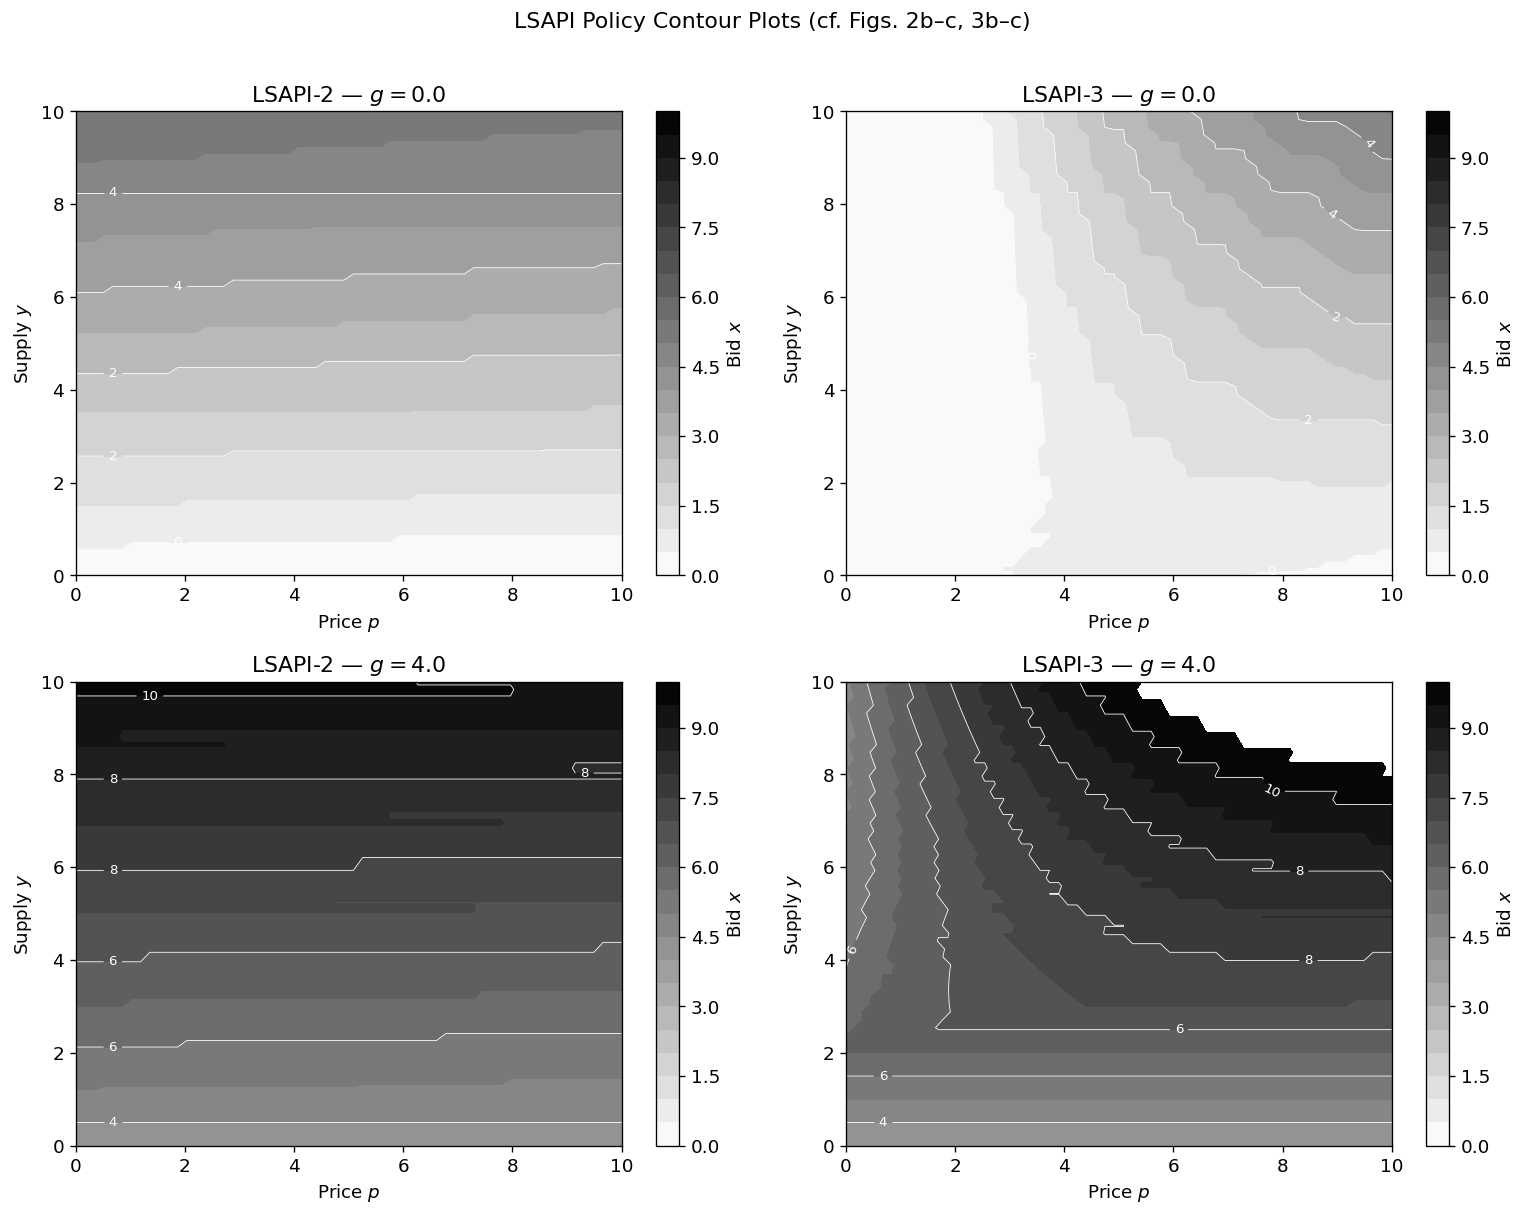

In [5]:
y_vals = np.linspace(0, 10, 60)
p_vals = np.linspace(0, 10, 60)
YY, PP = np.meshgrid(y_vals, p_vals, indexing='ij')

def bid_grid(approx, g_fixed, n_candidates=50):
    bids = np.zeros_like(YY)
    for i in range(len(y_vals)):
        for j in range(len(p_vals)):
            S = (float(YY[i, j]), float(PP[i, j]), g_fixed)
            bids[i, j] = _greedy_action(S, approx, env, n_candidates)
    return bids

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
configs = [(approx2, 'LSAPI-2'), (approx3, 'LSAPI-3')]
g_vals = [0.0, 4.0]

for col, (approx, label) in enumerate(configs):
    for row, g_fixed in enumerate(g_vals):
        ax = axes[row, col]
        bids = bid_grid(approx, g_fixed)
        cf = ax.contourf(PP, YY, bids, levels=np.linspace(0, 10, 21), cmap='gray_r')
        cs = ax.contour(PP, YY, bids, levels=np.arange(0.5, 10.5), colors='white', linewidths=0.5)
        ax.clabel(cs, inline=True, fontsize=8, fmt='%.0f')
        plt.colorbar(cf, ax=ax, label='Bid $x$')
        ax.set_xlabel('Price $p$')
        ax.set_ylabel('Supply $y$')
        ax.set_title(f'{label} — $g={g_fixed}$')

plt.suptitle('LSAPI Policy Contour Plots (cf. Figs. 2b–c, 3b–c)', y=1.01)
plt.tight_layout()
plt.show()

## 5. Reward comparison vs LP (Table 2)

In [6]:
# Load LP result if notebook 03 was run, otherwise just print LSAPI results
try:
    from lp_benchmark import solve_lp, lp_policy_fn, evaluate_policy
    Y_grid = np.arange(0, 11, dtype=float)
    P_grid = np.arange(0, 11, dtype=float)
    G_grid = np.arange(0, 5, dtype=float)
    X_grid = np.arange(0, 11, dtype=float)
    lp_result = solve_lp(Y_grid, P_grid, G_grid, X_grid, params, env)
    policy_lp = lp_policy_fn(lp_result)
    reward_lp = evaluate_policy(policy_lp, env, params, T_eval=10_000, seed=99)
    print(f"LP          discounted reward: {reward_lp:.2f}")
except Exception as e:
    reward_lp = None
    print(f"(LP not run: {e})")

print(f"LSAPI-2     discounted reward: {reward2:.2f}")
print(f"LSAPI-3     discounted reward: {reward3:.2f}")
if reward_lp is not None:
    print(f"\nLSAPI-2 vs LP: {(reward2 - reward_lp) / reward_lp * 100:+.1f}%")
    print(f"LSAPI-3 vs LP: {(reward3 - reward_lp) / reward_lp * 100:+.1f}%")
    print("(Paper: LSAPI-2 +3.5%, LSAPI-3 +4.0% over LP with full N=500, M=200)")

Building transition matrix...
Assembling LP...
Solving LP (605 variables, 6655 constraints)...
LP          discounted reward: 257.35
LSAPI-2     discounted reward: 256.42
LSAPI-3     discounted reward: 251.99

LSAPI-2 vs LP: -0.4%
LSAPI-3 vs LP: -2.1%
(Paper: LSAPI-2 +3.5%, LSAPI-3 +4.0% over LP with full N=500, M=200)


## 6. Effect of discount factor (Figure 4)

The paper shows that the multistage policy ($\gamma=0.9$) outperforms the myopic policy ($\gamma=0$) only when storage is present.

C=4.0, gamma=0.9: reward=235.06
C=4.0, gamma=0.0: reward=0.00
C=0.0, gamma=0.9: reward=198.91
C=0.0, gamma=0.0: reward=0.00


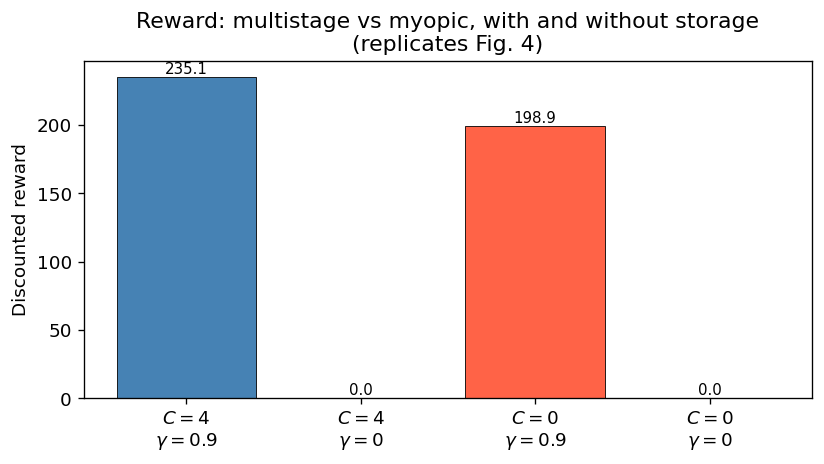

In [7]:
results_bar = {}
for C_val, gamma_val in [(4.0, 0.9), (4.0, 0.0), (0.0, 0.9), (0.0, 0.0)]:
    env_cfg = EnvParams(C=C_val, eta_plus=1.0, eta_minus=1.0, u=1.0, o=0.0, gamma=gamma_val)
    lp_cfg = LSAPIParams(N=200, M=50 if gamma_val > 0 else 1, buffer_size=5000,
                         epsilon=0.01, degree=2, n_action_candidates=30)
    rng_cfg = np.random.default_rng(0)
    approx_cfg = run_lsapi(env_cfg, params, lp_cfg, rng=rng_cfg, verbose=False)
    r = evaluate_lsapi(approx_cfg, env_cfg, params, T_eval=5000, seed=1)
    results_bar[(C_val, gamma_val)] = r
    print(f"C={C_val}, gamma={gamma_val}: reward={r:.2f}")

labels = ['$C=4$\n$\\gamma=0.9$', '$C=4$\n$\\gamma=0$', '$C=0$\n$\\gamma=0.9$', '$C=0$\n$\\gamma=0$']
vals = [results_bar[(4.0, 0.9)], results_bar[(4.0, 0.0)],
        results_bar[(0.0, 0.9)], results_bar[(0.0, 0.0)]]
colors = ['steelblue', 'lightsteelblue', 'tomato', 'lightsalmon']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, vals, color=colors, edgecolor='k', linewidth=0.5)
ax.set_ylabel('Discounted reward')
ax.set_title('Reward: multistage vs myopic, with and without storage\n(replicates Fig. 4)')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.1f}',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()